<a href="https://colab.research.google.com/github/lpatamia1/lpatamia1/blob/main/AmazonTopBooksPandasAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Amazon's Bestsellers Analysis**
This notebook analyzes Amazon's best selling books using pandas from 2009 to 2019 to uncover trends in ratings, reviews, pricing, and author success.


**Data Cleaning and Preparation**

First, we'll load the bestsellers.csv dataset and perform some essential cleaning. We will standardize column names (e.g., "User Rating" becomes user_rating) to make them easier to work with, check for any duplicate entries, and verify that all data is in the correct format.

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
import warnings

warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_csv('bestsellers.csv')

# Standardize column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
df.rename(columns={"name": "title", "user_rating": "rating"}, inplace=True)

# Handle duplicates
initial_rows = df.shape[0]
df.drop_duplicates(inplace=True)
print(f"Removed {initial_rows - df.shape[0]} duplicate rows.")

# Verify data types and check for nulls
print("\n--- Data Info ---")
df.info()

Removed 0 duplicate rows.

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550 entries, 0 to 549
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   title    550 non-null    object 
 1   author   550 non-null    object 
 2   rating   550 non-null    float64
 3   reviews  550 non-null    int64  
 4   price    550 non-null    int64  
 5   year     550 non-null    int64  
 6   genre    550 non-null    object 
dtypes: float64(1), int64(3), object(3)
memory usage: 30.2+ KB


**Correlation Heatmap**

With clean data, we can now search for patterns, trends, and relationships.

A correlation heatmap helps us quickly see how numerical variables relate to each other. Values close to 1 show a strong positive correlation, while values close to -1 show a strong negative correlation.



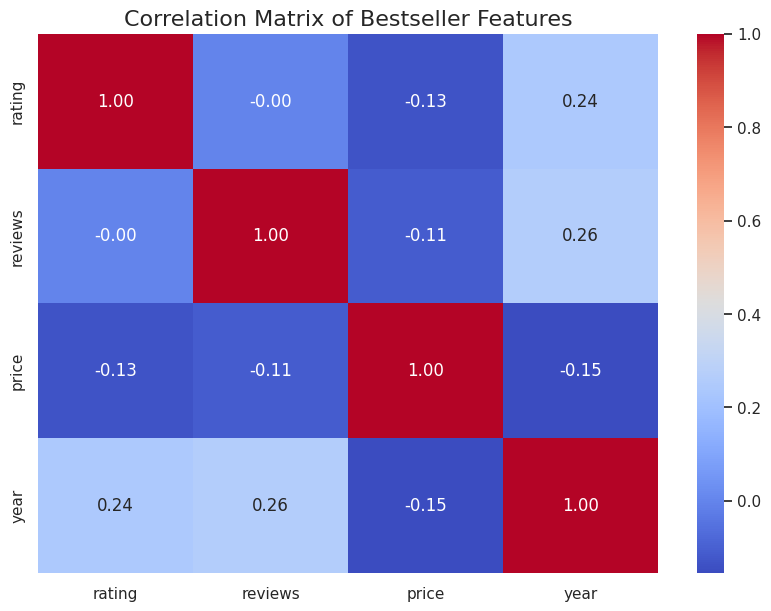

In [22]:
# Set the visual style for plots
sns.set_theme(style="whitegrid", palette="viridis")

# Generate the correlation matrix and heatmap
plt.figure(figsize=(10, 7))
numeric_cols = df.select_dtypes(include=['float64', 'int64'])
correlation_matrix = numeric_cols.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Bestseller Features', fontsize=16)
plt.show()

**Interpretation**: The heatmap reveals a notable positive correlation of +0.25 between a book's rating and the number of reviews it has. This suggests that books with higher ratings tend to have more reviews, which makes intuitive sense. Other correlations are weak.

**Time Series Analysis**

Plot key metrics and identify long-term trends from the average ratings, the number of reviews, and prices evolution from 2009 to 2019.

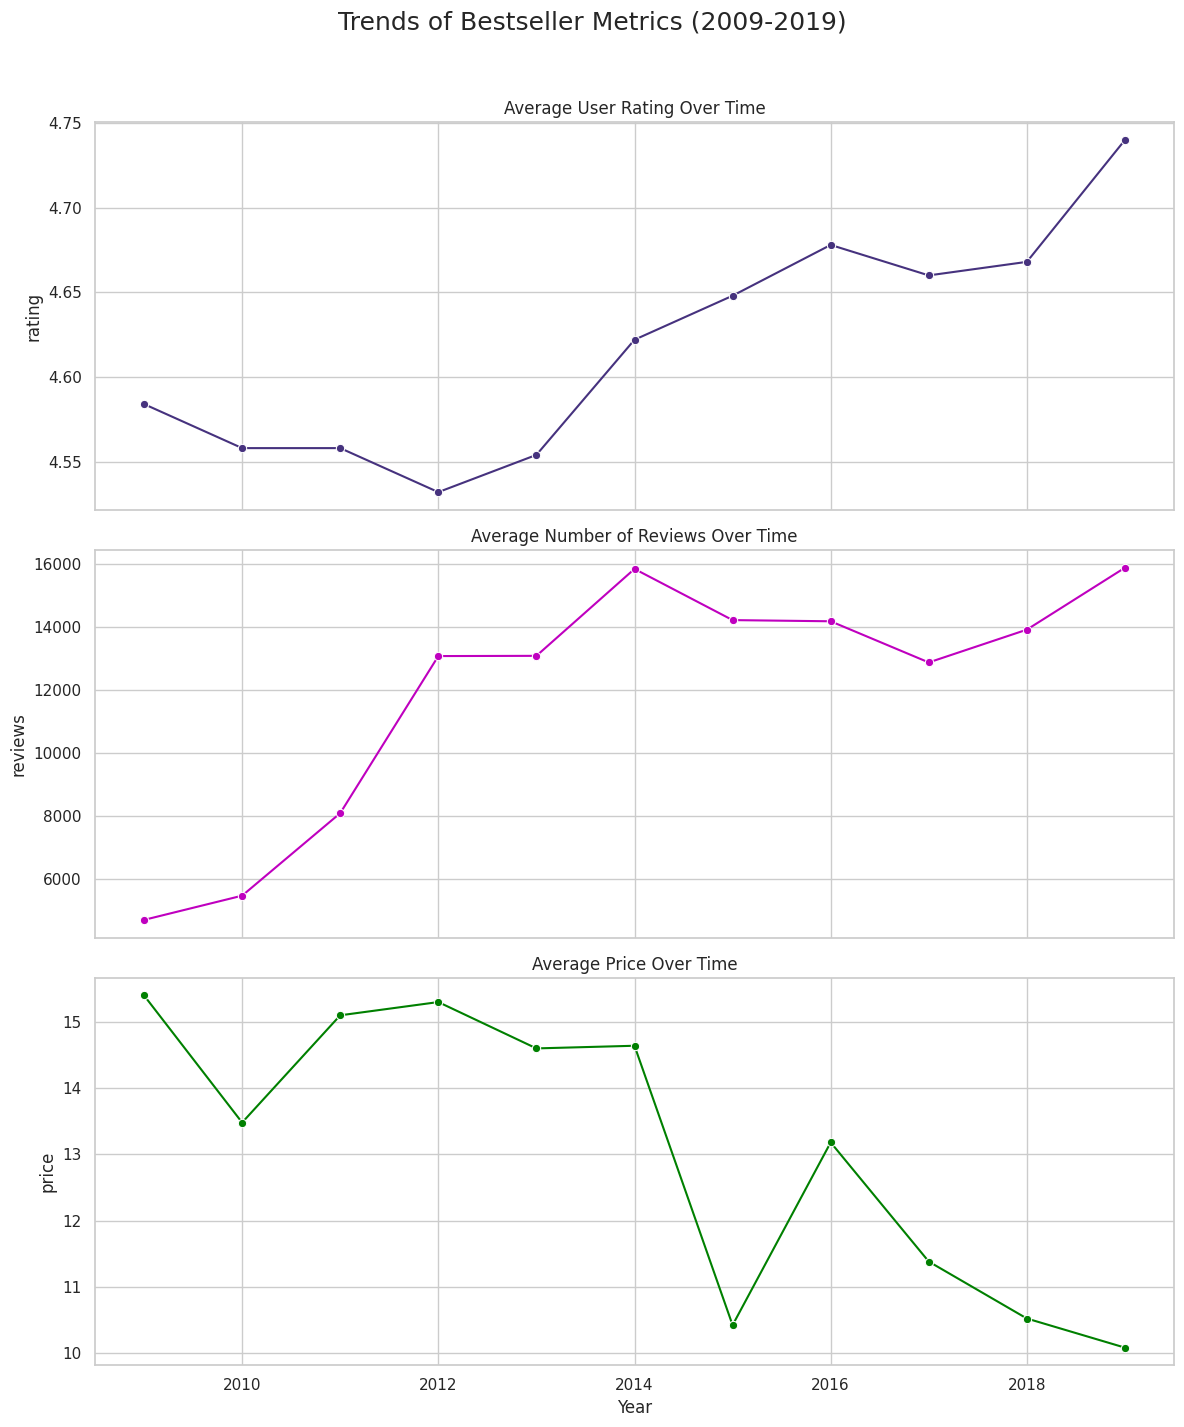

In [23]:
# Group data by year and calculate mean for key metrics
yearly_trends = df.groupby('year').agg({
    'rating': 'mean',
    'reviews': 'mean',
    'price': 'mean'
}).reset_index()

# Create subplots for each metric
fig, axes = plt.subplots(3, 1, figsize=(12, 15), sharex=True)
fig.suptitle('Trends of Bestseller Metrics (2009-2019)', fontsize=18)

# Plot Average User Rating
sns.lineplot(ax=axes[0], data=yearly_trends, x='year', y='rating', marker='o')
axes[0].set_title('Average User Rating Over Time')

# Plot Average Number of Reviews
sns.lineplot(ax=axes[1], data=yearly_trends, x='year', y='reviews', marker='o', color='m')
axes[1].set_title('Average Number of Reviews Over Time')

# Plot Average Price
sns.lineplot(ax=axes[2], data=yearly_trends, x='year', y='price', marker='o', color='g')
axes[2].set_title('Average Price Over Time')

plt.xlabel('Year')
plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

**Interpretation**: The analysis shows a maturing digital book market where, over ten years, bestsellers became significantly cheaper 📉 and received massively more reviews 📈, all while maintaining their high-quality user ratings ⭐. This suggests consumers got better value and more social proof without a drop in quality.

**Feature Engineering**

Create a new, insightful feature from the existing data. Create an author_prolificacy column to analyze is an author's output of bestsellers impacts their ratings.

author_prolificacy
Moderately Prolific    222
Highly Prolific        198
Single Bestseller      130
Name: count, dtype: int64


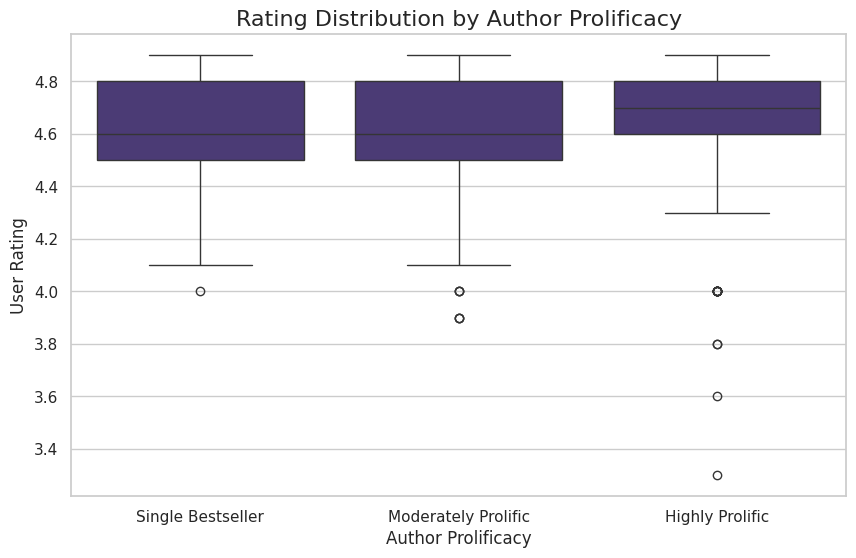

In [24]:
# Create the 'author_prolificacy' feature
author_counts = df['author'].value_counts()
def categorize_author(author):
    count = author_counts.get(author, 0)
    if count >= 5:
        return 'Highly Prolific'
    elif 1 < count < 5:
        return 'Moderately Prolific'
    else:
        return 'Single Bestseller'

df['author_prolificacy'] = df['author'].apply(categorize_author)

print(df['author_prolificacy'].value_counts())

# Visualize the relationship between prolificacy and rating
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='author_prolificacy', y='rating', order=['Single Bestseller', 'Moderately Prolific', 'Highly Prolific'])
plt.title('Rating Distribution by Author Prolificacy', fontsize=16)
plt.xlabel('Author Prolificacy')
plt.ylabel('User Rating')
plt.show()

**Interpretation**: This distribution shows that the Amazon bestseller list is heavily skewed towards established authors with a proven track record of success, as "Moderately Prolific" and "Highly Prolific" authors make up the vast majority of the list.

**Statistical Hypothesis Testing**

Next, we'll test if the difference in ratings between Fiction and Non-Fiction books is statistically significant.

**Hypothesis**: The average user ratings for Fiction books are different from those for Non-Fiction books.

In [25]:
# Separate the ratings for each genre
fiction_ratings = df[df['genre'] == 'Fiction']['rating']
non_fiction_ratings = df[df['genre'] == 'Non Fiction']['rating']

# Perform an independent t-test
t_stat, p_value = ttest_ind(fiction_ratings, non_fiction_ratings, equal_var=False)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

# Interpret the result
alpha = 0.05
if p_value < alpha:
    print("\n✅ Conclusion: The result is statistically significant. We can conclude there is a difference in average ratings between genres.")
else:
    print("\n❌ Conclusion: The result is not statistically significant. We cannot conclude there is a difference in average ratings.")

T-statistic: 2.6299
P-value: 0.0089

✅ Conclusion: The result is statistically significant. We can conclude there is a difference in average ratings between genres.


**Export Results**

Finally, we'll save our key findings and the enhanced dataset to new CSV files.



In [26]:
# Export top authors and average ratings by genre
author_counts.head(10).to_csv("top_authors.csv", header=['bestseller_count'])
df.groupby("genre")["rating"].mean().to_csv("avg_rating_by_genre.csv")

# Export the entire enhanced dataframe with the new feature
df.to_csv('bestsellers_enhanced.csv', index=False)

print("Exported 'top_authors.csv', 'avg_rating_by_genre.csv', and 'bestsellers_enhanced.csv'")

Exported 'top_authors.csv', 'avg_rating_by_genre.csv', and 'bestsellers_enhanced.csv'
